In [4]:

import networkx as nx
import matplotlib.pyplot as plt

edges = [
    ("A", "B"), ("A", "C"), ("A", "D"), ("A", "E"), ("A", "H"), ("A", "J"),
    ("B", "A"),
    ("C", "A"), ("C", "B"),
    ("D", "A"), ("D", "C"),
    ("E", "A"), ("E", "D"),
    ("F", "H"),
    ("G", "F"),
    ("H", "A"), ("H", "B"), ("H", "I"),
    ("I", "J"),
    ("J", "G"), ("J", "I"),
]

G = nx.DiGraph()
G.add_edges_from(edges)


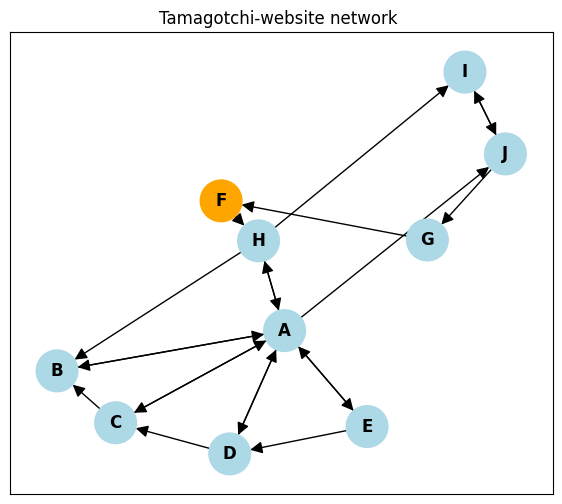

In [36]:

# network str
pos = nx.spring_layout(G)
plt.figure(figsize=(7, 6))
node_colors = ["orange" if n == "F" else "lightblue" for n in G.nodes()]
nx.draw_networkx(G, pos, node_color=node_colors, node_size=900,
                  arrowsize=18, font_weight="bold")
plt.title("Tamagotchi-website network ")
plt.show()


In [13]:

d = 0.85 

base_pr = nx.pagerank(G, alpha=d)

print("Baseline Pagerank")
for node, score in sorted(base_pr.items(), key=lambda x: -x[1]):
    print(f"  {node}: {score:.5f}")



Baseline Pagerank
  A: 0.21592
  J: 0.13279
  H: 0.10995
  B: 0.10785
  I: 0.10259
  F: 0.07572
  C: 0.07320
  G: 0.07143
  D: 0.06496
  E: 0.04559



## Part (a)


In [37]:

nodes = list(G.nodes())
results_a = []

for u in nodes:
    for v in nodes:
        if u == v or G.has_edge(u, v):
            continue
        G_test = G.copy()
        G_test.add_edge(u, v)
        pr = nx.pagerank(G_test, alpha=d)
        results_a.append((u, v, pr["F"]))

results_a.sort(key=lambda x: -x[2])


print(f"{'edge':>8} | {'PR(F)':>8}")

for u, v, val in results_a:
    print(f"{u+' to '+v:>8} | {val:8.5f} ")



    edge |    PR(F)
  B to F |  0.12011 
  F to G |  0.11215 
  B to G |  0.11037 
  H to F |  0.10040 
  A to F |  0.09964 
  I to F |  0.09632 
  C to F |  0.09564 
  A to G |  0.09452 
  H to G |  0.09434 
  B to J |  0.09376 
  D to F |  0.09373 
  C to G |  0.09177 
  F to J |  0.09147 
  D to G |  0.09028 
  J to F |  0.08992 
  B to I |  0.08923 
  I to G |  0.08874 
  E to F |  0.08861 
  F to I |  0.08670 
  E to G |  0.08617 
  C to J |  0.08466 
  H to J |  0.08420 
  D to J |  0.08391 
  A to I |  0.08273 
  C to I |  0.08259 
  D to I |  0.08205 
  E to J |  0.08165 
  E to I |  0.08032 
  B to H |  0.07793 
  D to H |  0.07706 
  C to H |  0.07705 
  E to H |  0.07672 
  E to B |  0.07562 
  D to B |  0.07551 
  E to C |  0.07541 
  D to E |  0.07494 
  C to E |  0.07473 
  C to D |  0.07473 
  F to A |  0.07422 
  F to B |  0.07302 
  B to C |  0.07282 
  B to D |  0.07282 
  B to E |  0.07282 
  F to C |  0.07253 
  F to D |  0.07232 
  F to E |  0.07223 
  H to C |  0.


## Part (b)


In [26]:

results_b = []

for v in nodes:
    if v == "F" or G.has_edge("F", v):
        continue
    G_test = G.copy()
    G_test.add_edge("F", v)
    pr = nx.pagerank(G_test, alpha=d)
    results_b.append((v, pr["F"]))

results_b.sort(key=lambda x: -x[1])

print(f"{'edge':>8} | {'PR(F)':>8}")
for v, val in results_b:
    print(f"{'F to '+v:>8} | {val:8.5f}")


    edge |    PR(F)
  F to G |  0.11215
  F to J |  0.09147
  F to I |  0.08670
  F to A |  0.07422
  F to B |  0.07302
  F to C |  0.07253
  F to D |  0.07232
  F to E |  0.07223
